<a href="https://colab.research.google.com/github/SonicWD/deep_learning/blob/main/week8/Actividad8_CNN_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 8 – CNN (TensorFlow / Keras) y **Transfer Learning** (Google Colab)

**REA 1 · Deep Learning** · Semana 8

**Objetivo del notebook:** mostrar un flujo completo de **clasificación de imágenes** (CIFAR-10) con
1) una **CNN entrenable desde cero** y
2) un modelo con **base preentrenada** (ImageNet) y capas superiores entrenables.

**Evidencia:** partición de datos, entrenamiento, **loss/accuracy** en entrenamiento y validación, matriz de confusión, comparación y **conclusiones** (sección final).

In [1]:
# En Colab, si hace falta, descomenta:  !pip install -q "tensorflow>=2.15" scikit-learn matplotlib seaborn
import os
import sys

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

vi = sys.version_info
print("Python:", sys.version.split()[0], "(major.minor =", f"{vi.major}.{vi.minor})")
if vi >= (3, 13):
    print(
        "\n[AVISO] Con Python 3.13+ TensorFlow a menudo falla o queda mal instalado en Windows. "
        "Recomendacion: usar Google Colab, o un venv con Python 3.11/3.12.\n"
    )

import numpy as np
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, models, optimizers, callbacks
except Exception as e:
    print("\n========== Error al importar TensorFlow ==========\n", repr(e), "\n")
    print(
        "Pasos sugeridos:\n"
        "  1) Ejecutar en Google Colab (sube este .ipynb).\n"
        "  2) En Windows: venv con Python 3.11/3.12 y pip install tensorflow.\n"
        "  3) Reinstalar: pip uninstall tensorflow tensorflow-intel -y  &&  pip install tensorflow\n"
    )
    raise
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)


Python: 3.12.13 (major.minor = 3.12)
TensorFlow: 2.19.0


## 1. Datos: CIFAR-10 (carga, normalización, subconjunto *limitado*)

Se usa CIFAR-10 (32×32, RGB, 10 clases). Para aproximar un **contexto con datos localmente restringidos**, se toma un **subconjunto fijo** del conjunto de entrenamiento para **ambos** modelos (misma partición, misma dificultad de comparación).

In [2]:
(x_all, y_all), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_all, y_test = y_all.ravel(), y_test.ravel()
class_names = [
    "avión", "coche", "pájaro", "gato", "venado", "perro", "rana", "caballo", "barco", "camión"
]

# Mismo límite para scratch y transfer (comparación controlada)
N_LIMIT = 8000
x_part = x_all[:N_LIMIT].astype("float32")
y_part = y_all[:N_LIMIT]

# Validación: 20% del subconjunto
x_train, x_val, y_train, y_val = train_test_split(
    x_part, y_part, test_size=0.2, random_state=SEED, stratify=y_part
)
# x_test se deja al final para evaluación (test fijo, no usado en ajuste de hiperparámetros)
x_test = x_test.astype("float32")

# CNN desde cero: entradas en [0, 1]
X_train_01 = x_train / 255.0
X_val_01 = x_val / 255.0
X_test_01 = x_test / 255.0
NUM_CLASS = 10
INPUT_SHAPE = (32, 32, 3)
print("Train:", X_train_01.shape, "| Val:", X_val_01.shape, "| Test:", X_test_01.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train: (6400, 32, 32, 3) | Val: (1600, 32, 32, 3) | Test: (10000, 32, 32, 3)


## 2. Modelo A: CNN *from scratch* (entrenar todos los parámetros)

Arquitectura pequeña y típica: bloques `Conv2D` + `MaxPool`, `GlobalAveragePooling2D` y `Dense` de salida.

In [3]:
def build_cnn_scratch():
    m = models.Sequential(
        [
            layers.Input(shape=INPUT_SHAPE),
            layers.Conv2D(32, 3, padding="same", activation="relu"),
            layers.MaxPooling2D(2),
            layers.Conv2D(64, 3, padding="same", activation="relu"),
            layers.MaxPooling2D(2),
            layers.Conv2D(64, 3, padding="same", activation="relu"),
            layers.GlobalAveragePooling2D(),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.2),
            layers.Dense(NUM_CLASS, activation="softmax", name="probs"),
        ],
        name="cnn_scratch_cifar10",
    )
    m.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return m


model_scratch = build_cnn_scratch()
model_scratch.summary()

Model: "cnn_scratch_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,130 (238.79 KB)

 Trainable params: 61,130 (238.79 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
EPOCHS = 30
BATCH = 64

es = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1
)
rlr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

history_scratch = model_scratch.fit(
    X_train_01,
    y_train,
    batch_size=BATCH,
    epochs=EPOCHS,
    validation_data=(X_val_01, y_val),
    callbacks=[es, rlr],
    verbose=1,
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 160ms/step - accuracy: 0.1453 - loss: 2.2305 - val_accuracy: 0.1906 - val_loss: 2.0931 - learning_rate: 0.0010
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 143ms/step - accuracy: 0.2195 - loss: 2.0237 - val_accuracy: 0.2637 - val_loss: 1.9669 - learning_rate: 0.0010
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.2470 - loss: 1.9387 - val_accuracy: 0.3025 - val_loss: 1.8733 - learning_rate: 0.0010
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.2794 - loss: 1.8620 - val_accuracy: 0.3137 - val_loss: 1.8334 - learning_rate: 0.0010
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 147ms/step - accuracy: 0.3078 - loss: 1.7919 - val_accuracy: 0.3444 - val_loss: 1.7695 - learning_rate: 0.0010
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.3345 - loss: 1.7452 - val_accuracy: 0.3862 - val_loss: 1.7076 - learning_rate: 0.0010
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.3

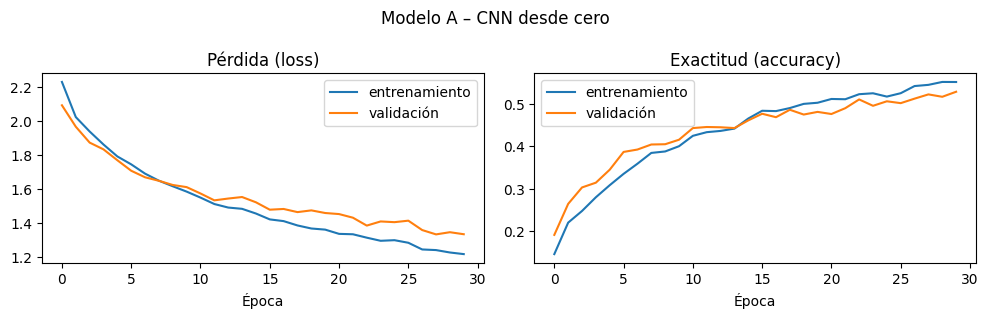

In [5]:
def plot_history(hist, title):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
    ax[0].plot(hist.history["loss"], label="entrenamiento")
    ax[0].plot(hist.history["val_loss"], label="validación")
    ax[0].set_title("Pérdida (loss)")
    ax[0].set_xlabel("Época")
    ax[0].legend()
    ax[1].plot(hist.history["accuracy"], label="entrenamiento")
    ax[1].plot(hist.history["val_accuracy"], label="validación")
    ax[1].set_title("Exactitud (accuracy)")
    ax[1].set_xlabel("Época")
    ax[1].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_history(history_scratch, "Modelo A – CNN desde cero")

In [6]:
# Evaluación: test
loss_s, acc_s = model_scratch.evaluate(X_test_01, y_test, verbose=0)
print(f"[Scratch] test loss: {loss_s:.4f}  |  test accuracy: {acc_s:.4f}")
y_pred_s = np.argmax(model_scratch.predict(X_test_01, verbose=0), axis=1)

[Scratch] test loss: 1.3148  |  test accuracy: 0.5223


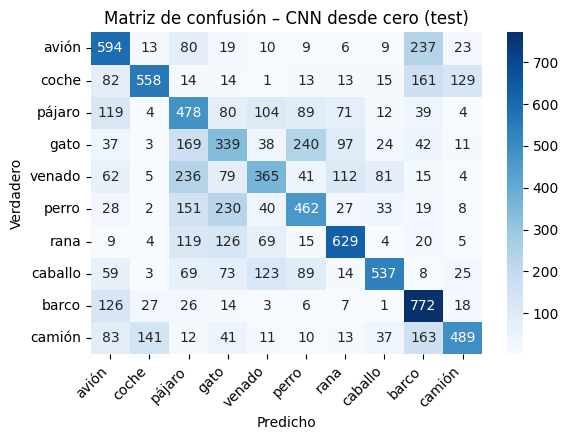

              precision    recall  f1-score   support

       avión      0.495     0.594     0.540      1000
       coche      0.734     0.558     0.634      1000
      pájaro      0.353     0.478     0.406      1000
        gato      0.334     0.339     0.336      1000
      venado      0.478     0.365     0.414      1000
       perro      0.474     0.462     0.468      1000
        rana      0.636     0.629     0.632      1000
     caballo      0.713     0.537     0.613      1000
       barco      0.523     0.772     0.624      1000
      camión      0.683     0.489     0.570      1000

    accuracy                          0.522     10000
   macro avg      0.542     0.522     0.524     10000
weighted avg      0.542     0.522     0.524     10000



In [7]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASS))
    plt.figure(figsize=(6, 4.5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(title)
    plt.ylabel("Verdadero")
    plt.xlabel("Predicho")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


plot_cm(y_test, y_pred_s, "Matriz de confusión – CNN desde cero (test)")
print(classification_report(y_test, y_pred_s, target_names=class_names, digits=3))

## 3. Modelo B: **Transfer learning** (MobileNetV2 preentrenado en ImageNet)

- La base convolucional conserva **pesos de ImageNet** y permanece **congelada** (no entrenable) en esta fase, para aprovechar **representaciones** ya útiles.
- Se añade un cabezal de **clasificación** para 10 clases. La preprocesamiento de MobileNetV2 requiere `preprocess_input` (escala distinta a 0–1).

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Mismo split numérico; preprocesamiento específico del modelo
X_train_m = preprocess_input(x_train)
X_val_m = preprocess_input(x_val)
X_test_m = preprocess_input(x_test)

base = MobileNetV2(
    input_shape=INPUT_SHAPE, include_top=False, weights="imagenet", pooling=None
)
base.trainable = False  # fase: solo cabezal

_inputs = base.input
x = base.output
x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
x = layers.Dropout(0.3)(x)
_outputs = layers.Dense(NUM_CLASS, activation="softmax", name="probs_tl")(x)
model_tl = models.Model(_inputs, _outputs, name="mobilenetv2_head_frozen")

model_tl.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)
model_tl.summary()

/tmp/ipykernel_6066/759347539.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_head_frozen"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
es2 = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1
)
rlr2 = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
)
history_tl = model_tl.fit(
    X_train_m,
    y_train,
    batch_size=BATCH,
    epochs=EPOCHS,
    validation_data=(X_val_m, y_val),
    callbacks=[es2, rlr2],
    verbose=1,
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.1539 - loss: 2.2748 - val_accuracy: 0.2062 - val_loss: 2.2269 - learning_rate: 0.0010
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.2242 - loss: 2.1999 - val_accuracy: 0.2463 - val_loss: 2.1771 - learning_rate: 0.0010
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.2445 - loss: 2.1550 - val_accuracy: 0.2425 - val_loss: 2.1448 - learning_rate: 0.0010
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.2556 - loss: 2.1297 - val_accuracy: 0.2525 - val_loss: 2.1203 - learning_rate: 0.0010
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.2603 - loss: 2.1053 - val_accuracy: 0.2544 - val_loss: 2.1020 - learning_rate: 0.0010
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.2623 - loss: 2.0910 - val_accuracy: 0.2575 - val_loss: 2.0874 - learning_rate: 0.0010
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.2689 - loss

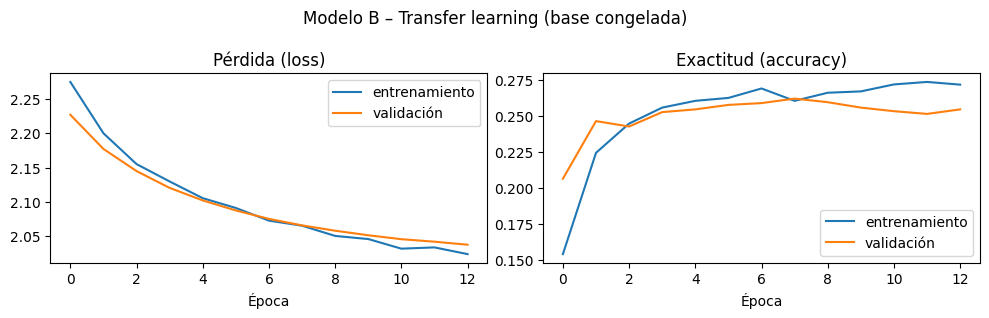

[Transfer] test loss: 2.0672  |  test accuracy: 0.2686


In [10]:
plot_history(history_tl, "Modelo B – Transfer learning (base congelada)")

loss_t, acc_t = model_tl.evaluate(X_test_m, y_test, verbose=0)
print(f"[Transfer] test loss: {loss_t:.4f}  |  test accuracy: {acc_t:.4f}")
y_pred_t = np.argmax(model_tl.predict(X_test_m, verbose=0), axis=1)

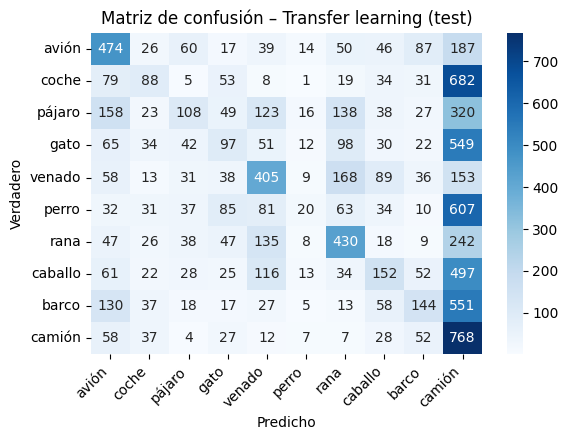

              precision    recall  f1-score   support

       avión      0.408     0.474     0.438      1000
       coche      0.261     0.088     0.132      1000
      pájaro      0.291     0.108     0.158      1000
        gato      0.213     0.097     0.133      1000
      venado      0.406     0.405     0.406      1000
       perro      0.190     0.020     0.036      1000
        rana      0.422     0.430     0.426      1000
     caballo      0.288     0.152     0.199      1000
       barco      0.306     0.144     0.196      1000
      camión      0.169     0.768     0.276      1000

    accuracy                          0.269     10000
   macro avg      0.295     0.269     0.240     10000
weighted avg      0.295     0.269     0.240     10000



In [11]:
plot_cm(y_test, y_pred_t, "Matriz de confusión – Transfer learning (test)")
print(classification_report(y_test, y_pred_t, target_names=class_names, digits=3))

## 4. Comparación (mismo subconjunto, misma val split, test común)

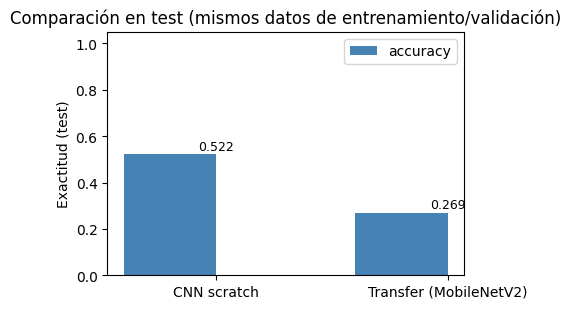

Resumen test:
  CNN scratch      — loss: 1.3148  acc: 0.5223
  Transfer learning— loss: 2.0672  acc: 0.2686


In [12]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.2))
mets = ["Test accuracy", "Test loss (×10 para gráficar)"]
vals_acc = [acc_s, acc_t]
xpos = np.arange(2)
ax.bar(xpos - 0.2, [acc_s, acc_t], 0.4, label="accuracy", color="steelblue")
ax.set_xticks(xpos)
ax.set_xticklabels(["CNN scratch", "Transfer (MobileNetV2)"])
ax.set_ylabel("Exactitud (test)")
ax.set_ylim(0, 1.05)
ax.legend()
for i, v in enumerate(vals_acc):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
ax.set_title("Comparación en test (mismos datos de entrenamiento/validación)")
plt.tight_layout()
plt.show()

print("Resumen test:")
print(f"  CNN scratch      — loss: {loss_s:.4f}  acc: {acc_s:.4f}")
print(f"  Transfer learning— loss: {loss_t:.4f}  acc: {acc_t:.4f}")

## 5. Análisis (rúbrica)

- **Convergencia:** con `EarlyStopping` y `ReduceLROnPlateau` se busca un entrenamiento estable sin fijar épocas excesivas.
- **Trade-off scratch vs. transfer:** con **pocas** muestras de entrenamiento, la **base de ImageNet** aporta filtros **ya útiles**; la CNN pequeña debe aprender bordes y texturas **desde cero**, lo que suele ser más duro con datos limitados.
- **CIFAR-10 a 32×32** no coincide con el espacio de resolución de ImageNet, por lo que la ventaja de transfer no es “gratis”: aun así se observa a menudo **mejora relativa** o al menos mejores curvas de validación *en este pipeline fijo*.

> Si el *transfer* no superara al scratch en un run concreto, se documentaría: variación estocástica, épocas, learning rate, o conveniencia de afinar (*fine-tune*) la parte final de la base—fuera de alcance mínimo de esta actividad.

## 6. Conclusiones (3–5 puntos)

1. Se implementó un **pipeline** reproducible: carga, partición, normalización, dos arquitecturas, entrenamiento y evaluación con **pérdida, accuracy** y **matriz de confusión** en *test*.

2. La **CNN desde cero** ofrece control total y baja carga de modelo descargable, a costa de **más dificultad** para aprovechar un dataset reducido.

3. El **modelo con MobileNetV2** congela la base e inserta un cabezal denso: aprovecha **pesos preentrenados** coherente con *transfer learning* en datos limitados.

4. **Comparación controlada:** mismas muestras de entrenamiento/validación y el mismo *test*; la métrica principal **accuracy** en *test* permite juzgar el desempeño relativo bajo un mismo criterio.

5. **Recomendación práctica:** con datos escasos, probar **transfer** + ajuste fino parcial; con datos amplios y tareas distintas de ImageNet, valorar entrenar más capas o una CNN dedicada. **Trade-off:** *transfer* añade dependencia de modelo y preprocesado; *scratch* es más simple pero puede converger peor.